# Unemployment Analysis with Python

## Objective

Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

## Dataset

Dataset: Unemployment in India.
**Source: Kaggle**

The dataset contains:
- Region
- Date
- Frequency
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area


## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


## 2. Load Dataset
The dataset is hosted in my GitHub repository and loaded directly using its raw GitHub URL.
**Original Source: Kaggle**


In [4]:
url = "https://raw.githubusercontent.com/SiamWR/OIBSIP/refs/heads/main/DataScience-Task2-UnemploymentAnalysis/Dataset/Unemployment%20in%20India.csv"

df = pd.read_csv(url)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 3. Data Loading and Inspection

This section performs:
- dataset shape checking
- data type inspection
- null value checking
- required type conversion


In [5]:
# Dataset shape

df.shape


(768, 7)

In [6]:
# Dataset information and data types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [7]:
# Missing value check

df.isnull().sum()


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
# Clean column names

df.columns = df.columns.str.strip()

# Convert date column

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## 4. Exploratory Data Analysis (EDA)

Regional and temporal unemployment patterns are analyzed through statistics and visualizations.


In [9]:
# Region-wise average unemployment rates

region_average = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_average


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

### Observation

The regional average unemployment rate highlights differences in unemployment levels across Indian states/regions.


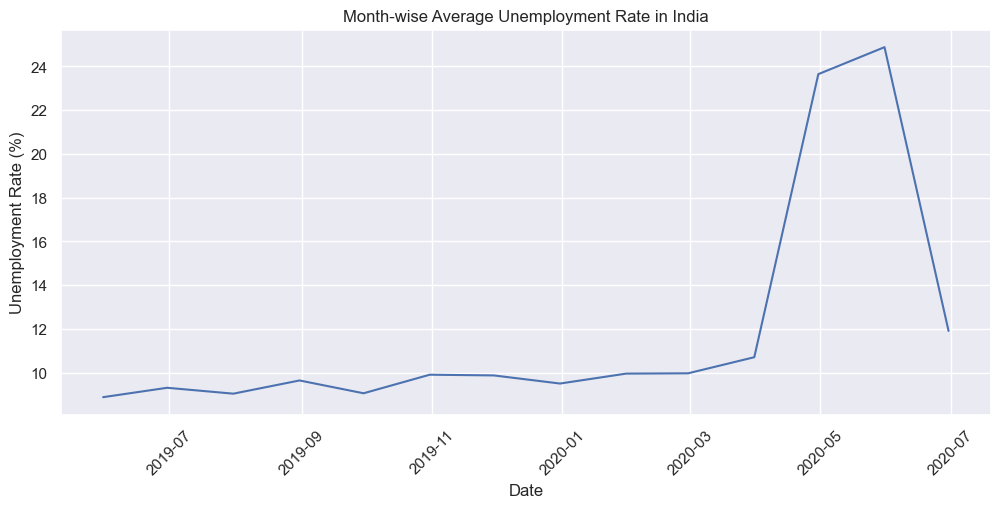

In [17]:
# Month-wise unemployment trend

monthly_trend = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(monthly_trend.index, monthly_trend.values)
plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
import os
os.makedirs("outputs/figures", exist_ok=True)
plt.savefig(
    "outputs/figures/monthly_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The time-series trend shows how unemployment changed over different months, including the period affected by COVID-19.


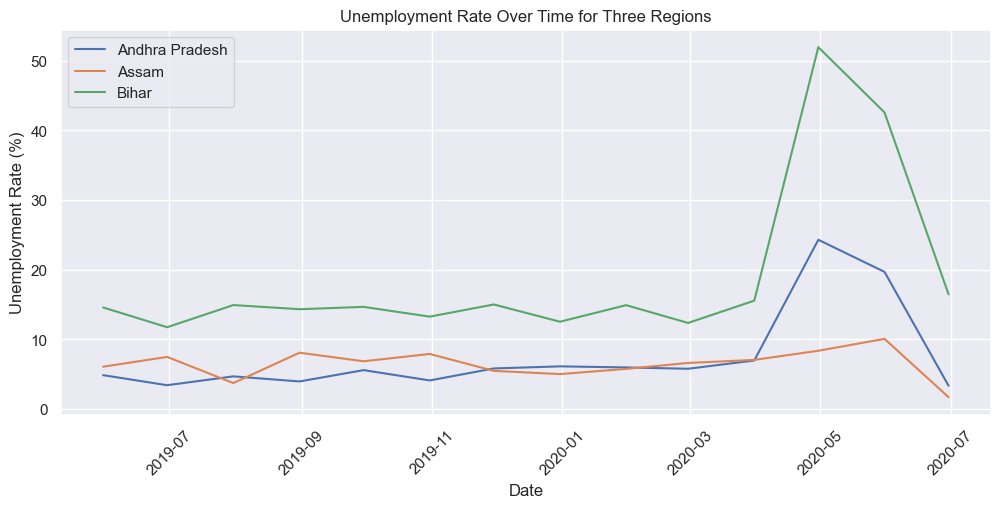

In [18]:
# Unemployment trend over time for three major regions

selected_regions = df["Region"].dropna().unique()[:3]

plt.figure(figsize=(12,5))

for region in selected_regions:
    temp = (
        df[df["Region"] == region]
        .groupby("Date")["Estimated Unemployment Rate (%)"]
        .mean()
    )
    plt.plot(temp.index, temp.values, label=region)

plt.title("Unemployment Rate Over Time for Three Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.savefig(
    "outputs/figures/three_regions_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

The comparison of multiple regions shows differences in unemployment trends over time.


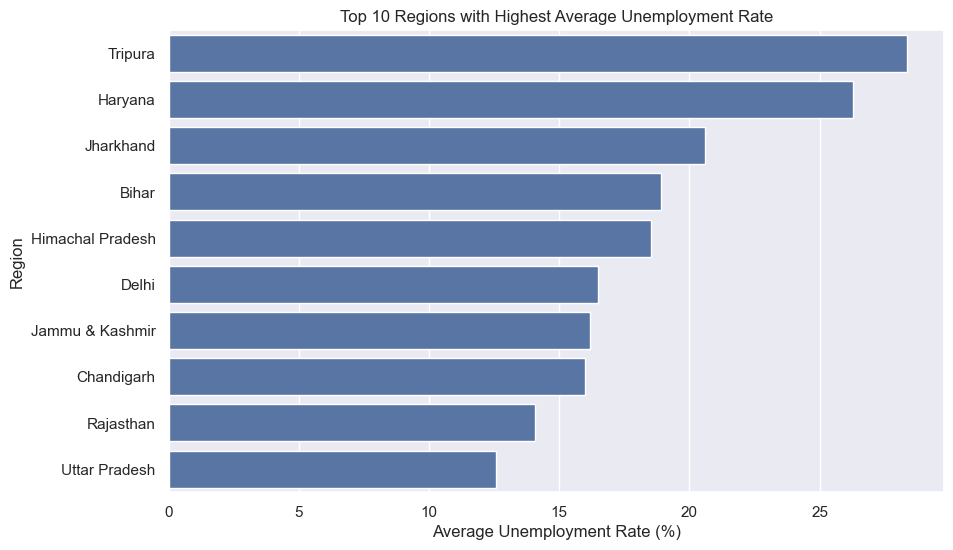

In [19]:
# Top 10 regions with highest average unemployment rate

top_10 = region_average.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_10.values, y=top_10.index)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.savefig(
    "outputs/figures/top10_regions_unemployment_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Observation

The bar chart identifies regions with the highest average unemployment rates during the study period.


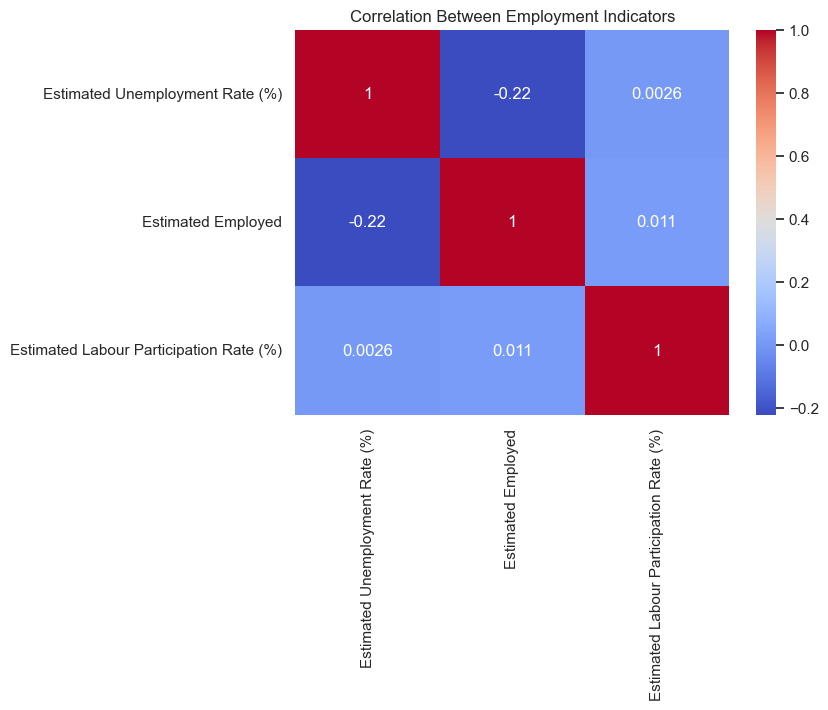

In [20]:
# Correlation heatmap

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[correlation_columns].corr()

plt.figure(figsize=(7,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Between Employment Indicators")
plt.savefig(
    "outputs/figures/employment_indicators_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Observation

The heatmap shows relationships between unemployment rate, employment level, and labour participation rate.


## 5. Pre-COVID vs Post-COVID Comparison

The dataset is divided by date to compare average unemployment rates before and after the COVID-19 period.


In [14]:
covid_date = pd.Timestamp("2020-03-01")

df["COVID_Period"] = np.where(
    df["Date"] < covid_date,
    "Pre-COVID",
    "Post-COVID"
)

covid_comparison = (
    df.groupby("COVID_Period")["Estimated Unemployment Rate (%)"]
    .mean()
)

covid_comparison

COVID_Period
Post-COVID    17.774363
Pre-COVID      9.509534
Name: Estimated Unemployment Rate (%), dtype: float64

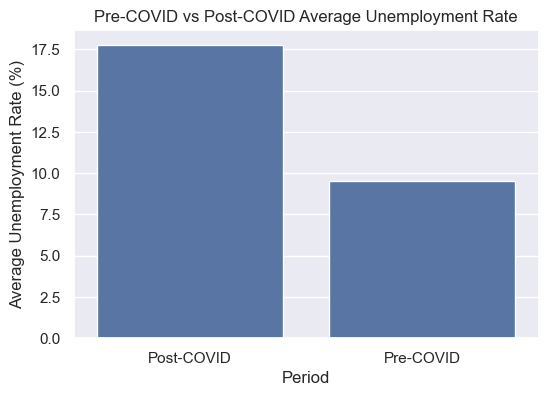

In [21]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison.values
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.savefig(
    "outputs/figures/pre_post_covid_unemployment_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The comparison evaluates the change in average unemployment rate between the pre-COVID and post-COVID periods.


## 6. Conclusion

Key findings:

- Unemployment rates vary across Indian regions.
- Monthly trends reveal changes in unemployment over time.
- Regional comparisons show different unemployment patterns.
- COVID-19 period analysis helps understand changes in unemployment levels.
